In [ ]:
# Load required packages
required_packages = ["DataFrames","LinearAlgebra","Statistics", "MAT","Random", "Plots","Zygote", "Measures", "PyPlot","Arpack","SparseArrays","LIBSVM"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

In [ ]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Measures
using PyPlot
using Arpack
using SparseArrays
#______________________________________________________________________________#

#_________________________________setting problem______________________________#
#                                   ---LS---                                   #
#______________________________________________________________________________#
Random.seed!(23)
m, n = 20000, 1000

# Generate ILL-CONDITIONED A (key to slow convergence)
# Condition number ~ 50
U, _ = qr(randn(m, n))
V, _ = qr(randn(n, n))
cond_num = 50.0
Σ = diagm(0 => [cond_num^(-(i-1)/(n-1)) for i in 1:n])  # Decaying singular values
A = U * Σ * V'

# Generate x_star SPARSE
# We want x_star to have many nonzeros → forces FW to combine many vertices
k = 50  # number of nonzeros — large enough to make it hard
x_star = zeros(n)
indices = randperm(n)[1:k]
x_star[indices] = randn(k)

# Add small noise so solution isn’t trivial
noise_level = 1e-2
b = A * x_star + noise_level * randn(m)

# Objective and gradient
f(x) = sum((A*x - b).^2)
grad_f(x) = 2 * A' * (A*x - b)
#
L = 2 * maximum(eigvals(A' * A))
println("Lipschitz constant (L): $L")

# STABLE Lipschitz constant — use known Σ
L = 2 * Σ[1]^2
println("Lipschitz constant (L): $L")  # Should be 2*(100.0)^2 = 20000.0
#
rho = 1  # radius of ball
# Linear Minimization Oracle (LMO) unit l_2 ball
function lmo(g; rho=1)
    norm_g = norm(g, 2)
    return norm_g > 0 ? -rho * g / norm_g : zeros(length(g))
end
# Linear Minimization Oracle (LMO) unit l_1 ball
function lmo1(g; rho=1)
    n = length(g)
    abs_g = abs.(g)
    j = argmax(abs_g)  # Index of maximum absolute value
    result = zeros(n)
    result[j] = -rho * sign(g[j])
    return result
end
# Linear Minimization Oracle (LMO) unit l_inf ball
function lmo_inf(g; rho=1)
    return -rho * sign.(g)
end
#
x0 = zeros(n)
max_iter = 3000

Lipschitz constant (L): 1.9999999999999964
Lipschitz constant (L): 2.0


3000

In [ ]:
#AdaBB: Adaptive Barzilai-Borwein Algorithm#
function adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)
    println("\e[33m____________________AdaBB_________________________")

    # Initialize
    x_prev = copy(x0)
    grad_prev = grad_f(x_prev)

    # First step: x^1 = x^0 - alpha_0 * grad f(x^0)
    x = x_prev - alpha0 * grad_prev

    # Compute lambda_1 to determine theta_0
    grad_curr = grad_f(x)
    s_1 = x - x_prev
    y_1 = grad_curr - grad_prev
    lambda_1 = dot(y_1, s_1) / dot(y_1, y_1)

    # Compute theta_0 based on lambda_1
    if lambda_1 >= sqrt(2) * alpha0
        theta0 = lambda_1^2 / (2 * alpha0^2) - 1.0
    else
        theta0 = 0.0
    end
    println("lambda_1 = $(round(lambda_1, digits=8)), theta_0 = $(round(theta0, digits=8))")

    alpha_km1 = alpha0      # alpha_{k-1}
    theta_km1 = theta0      # theta_{k-1}

    values = [f(x_prev), f(x)]
    times = [0.0]
    gaps = Float64[]
    steps = [alpha0]

    k = 1
    while k < max_iter
        start = time()

        # Reuse grad_curr from theta_0 computation on first iteration
        if k > 1
            grad_curr = grad_f(x)
        end

        # Compute differences
        s_k = x - x_prev               # x^k - x^{k-1}
        y_k = grad_curr - grad_prev    # grad f(x^k) - grad f(x^{k-1})

        # Compute lambda_k (BB step size)
        lambda_k = dot(y_k, s_k) / dot(y_k, y_k)

        # Adaptive step-size selection
        if lambda_k >= alpha_km1
            alpha_k = sqrt(1 + theta_km1) * alpha_km1
            theta_k = alpha_k / alpha_km1
        elseif alpha_km1 / 2 < lambda_k < alpha_km1
            # Case (i)
            alpha_k = lambda_k
            theta_k = 2 * alpha_k / alpha_km1 - alpha_k / lambda_k
        else
            # Case (iii)
            alpha_k = lambda_k / sqrt(2)
            theta_k = alpha_k / alpha_km1
        end

        # Update iterates
        x_prev = copy(x)
        grad_prev = copy(grad_curr)
        x = x - alpha_k * grad_curr

        f_curr = f(x)
        gap = norm(grad_prev)

        k += 1
        iteration_time = time() - start

        push!(gaps, gap)
        push!(values, f_curr)
        push!(times, iteration_time)
        push!(steps, alpha_k)

        # Update for next iteration
        alpha_km1 = alpha_k
        theta_km1 = theta_k

        # Termination check
        if gap <= epsilon
            println(">>> ____________________ Terminated at k=$k, Grad Norm: $(round(gap, digits=6))____________________")
            break
        end

        if k % 100 == 0
            println("k $k: Gap = $(round(gap, digits=6)), alpha_k = $(round(alpha_k, digits=8)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f_curr, digits=6))")
        end
    end

    println("k $k: Gap = $(round(gaps[end], digits=6)), alpha_k = $(round(steps[end], digits=8)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("AdaBB Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x), digits=6))")
    println("____________________________________________________________\e[0m")

    return (x, values, times, gaps, steps)
end

adabb (generic function with 1 method)

In [ ]:
#____________________________________Run AdaBB_________________________________#

alpha0 = 10^(-10)

# Run AdaBB
results_adabb = adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)

# Save results
output_dir = "/content/output"
mkpath(output_dir)

MAT.matwrite(joinpath(output_dir, "results_adabb.mat"), Dict(
    "x"      => results_adabb[1],
    "values" => results_adabb[2],
    "times"  => results_adabb[3],
    "gaps"   => results_adabb[4],
    "steps"  => results_adabb[5]
))
println("Saved: ", joinpath(output_dir, "results_adabb.mat"))

____________________AdaBB_________________________
lambda_1 = 0.6656023, theta_0 = 2.215132124834853e19
k 100: Gap = 2.016139, alpha_k = 1.3902521, Time = 0.0411 sec, f_k = 243.917078
k 200: Gap = 0.558684, alpha_k = 0.67170055, Time = 0.0451 sec, f_k = 41.128995
k 300: Gap = 0.242619, alpha_k = 2.36628701, Time = 0.0431 sec, f_k = 13.68032
k 400: Gap = 0.138975, alpha_k = 1.04322497, Time = 0.0454 sec, f_k = 6.913679
k 500: Gap = 0.094371, alpha_k = 0.7585981, Time = 0.0502 sec, f_k = 4.648424
k 600: Gap = 0.064137, alpha_k = 2.19114957, Time = 0.041 sec, f_k = 3.319568
k 700: Gap = 0.048579, alpha_k = 1.79195614, Time = 0.0406 sec, f_k = 2.753757
k 800: Gap = 0.037705, alpha_k = 0.3987929, Time = 0.0481 sec, f_k = 2.443196
k 900: Gap = 0.029616, alpha_k = 1.46445172, Time = 0.0411 sec, f_k = 2.249947
k 1000: Gap = 0.023651, alpha_k = 3.78825936, Time = 0.0409 sec, f_k = 2.125708
k 1100: Gap = 0.019054, alpha_k = 0.42870191, Time = 0.042 sec, f_k = 2.047822
k 1200: Gap = 0.015529, alp

✅ Saved: LS_L.eps


sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


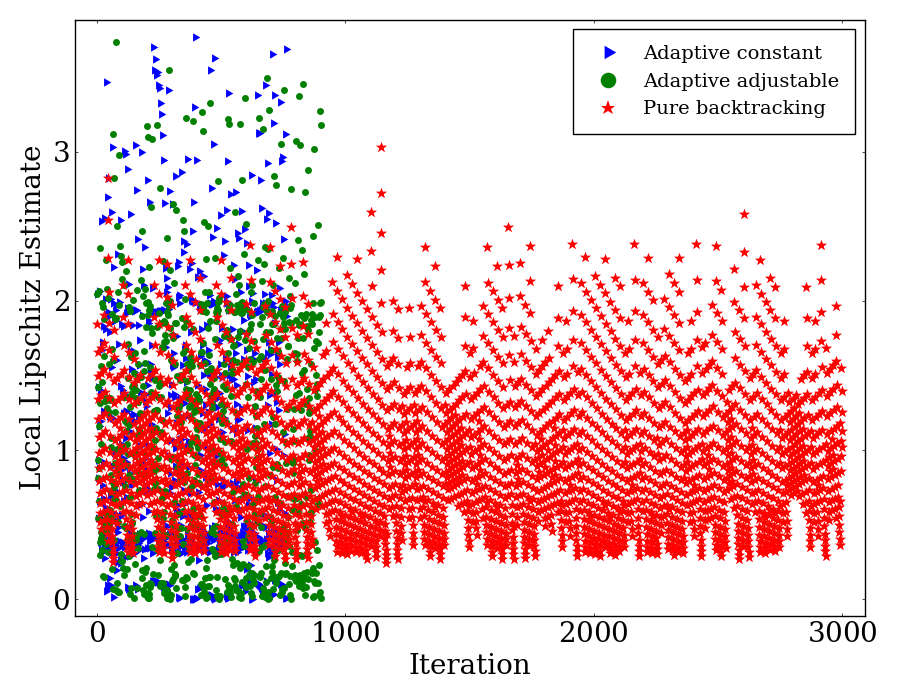

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


✅ Saved: LS_Gap.eps


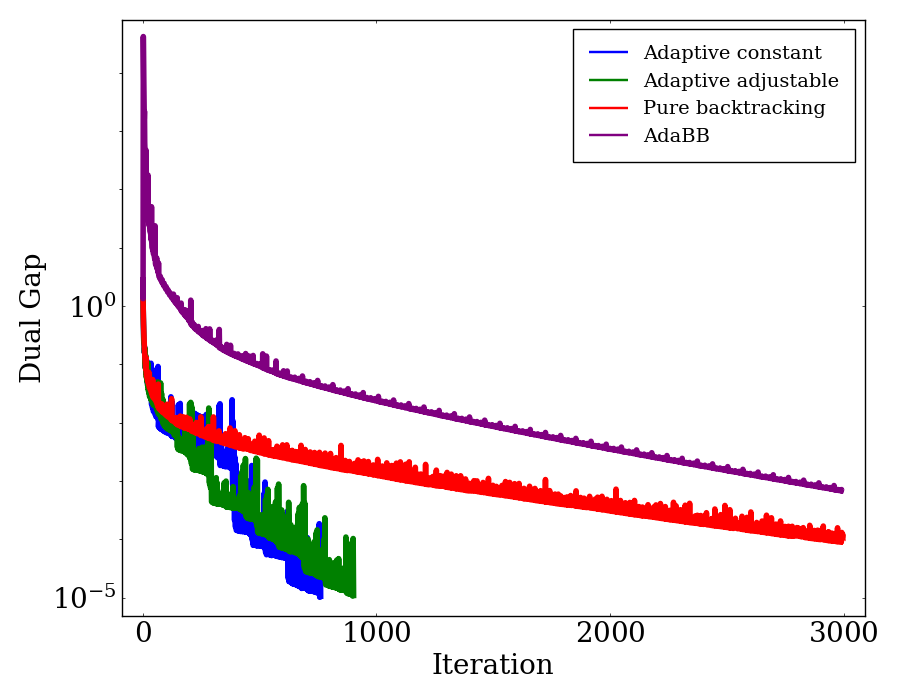

✅ Saved: LS_Gap_vs_time.eps


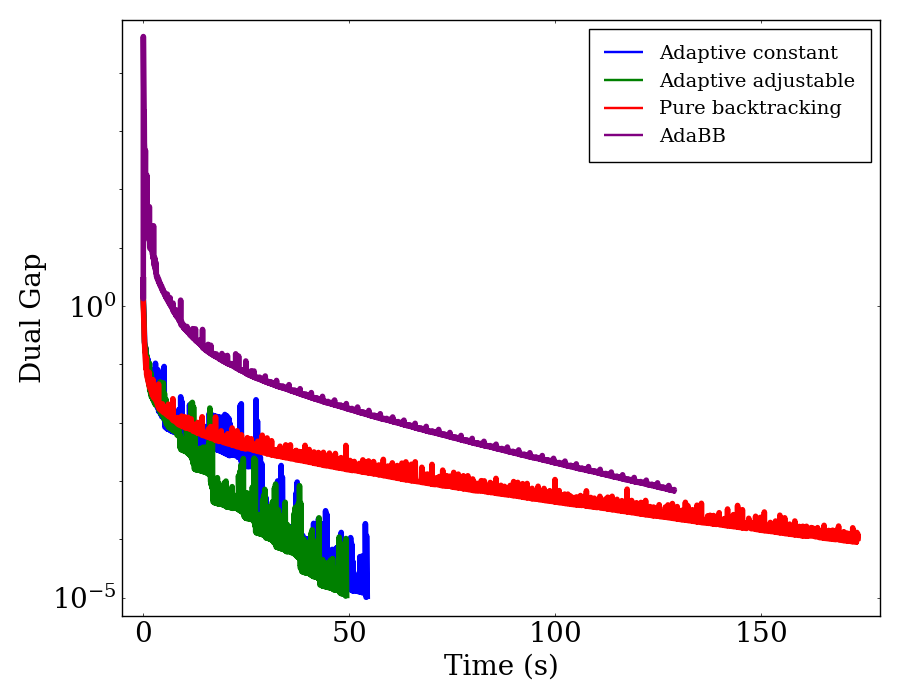


🎉 All plots saved as EPS in: /content/output



[299] signal 11 (1): Segmentation fault
in expression starting at none:1
PyObject_GC_Del at /usr/lib/x86_64-linux-gnu/libpython3.12.so.1.0 (unknown line)
pydecref_ at /root/.julia/packages/PyCall/1gn3u/src/PyCall.jl:118


In [ ]:

# Ensure all necessary packages are loaded
using DataFrames, LinearAlgebra, Statistics, MAT, Random, Plots, Measures, CSV, Arpack, Downloads, SparseArrays

# ⚠️ Use PyPlot backend — works reliably in Colab and supports EPS
using PyPlot
pyplot()

output_dir = "/content/output"  # Changed to distinguish from logistic output
mkpath(output_dir)


# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
ada = matread(joinpath(output_dir, "results_adabb.mat"))
#________________________ PLOTTING FUNCTION (LEGEND ORDER = TABLE ORDER) ________________________#
function create_and_save_plots()
    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times = [0.0; cumsum(ped["times"][1:end-1])]
    ada_cum_times = [0.0; cumsum(ada["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (20, "serif"),
        :guidefont => (20, "serif"),
        :tickfont => (20, "serif"),
        :legendfont => (14, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # --- PLOT 1: Lipschitz Constants (AdaBB uses step sizes instead) ---
    p1 = Plots.plot()
    # 1. Plot RED first — hidden from legend (drawn underneath)
    Plots.plot!(p1, ped["L_ks"],
                label=false,
                color=:red,
                seriestype=:scatter,
                markersize=8,
                marker=:star5,
                markerstrokewidth=0)

    # 2. Plot BLUE — appears in legend
    Plots.plot!(p1, our["L_ks"],
                label="Adaptive constant",
                color=:blue,
                seriestype=:scatter,
                markersize=7,
                marker=:rtriangle,
                markerstrokewidth=0)

    # 3. Plot GREEN — appears in legend
    Plots.plot!(p1, our5["L_ks"],
                label="Adaptive adjustable",
                color=:green,
                seriestype=:scatter,
                markersize=5,
                marker=:circle,
                markerstrokewidth=0)

    # 4. Plot RED again — now add to legend (appears LAST in legend)
    Plots.plot!(p1, ped["L_ks"],
                label="Pure backtracking",
                color=:red,
                seriestype=:scatter,
                markersize=8,
                marker=:star5,
                markerstrokewidth=0)


    # Set axis labels and style
    Plots.plot!(p1,
            xlabel="Iteration",
            ylabel="Local Lipschitz Estimate";
            style...)

    Plots.savefig(p1, joinpath(output_dir, "LS_L.eps"))
    println("✅ Saved: LS_L.eps")
    display(p1)

    # --- PLOT 2: Gradient Norm vs Iteration ---
    p2 = Plots.plot(our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Gradient Norm";
                    style...)
    Plots.plot!(p2, our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p2, our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p2, ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p2, ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "LS_Gap.eps"))
    println("✅ Saved: LS_Gap.eps")
    display(p2)

    # --- PLOT 3: Gradient Norm vs Time ---
    p3 = Plots.plot(our_cum_times[1:end-1], our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    yscale=:log10,
                    xlabel="Time (s)",
                    ylabel="Gradient Norm",
                    markersize=7;
                    style...)
    Plots.plot!(p3, our_cum_times[1:end-1], our["gaps"],
                label=false,
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p3, our5_cum_times[1:end-1], our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p3, ped_cum_times[1:end-1], ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)
    Plots.plot!(p3, ada_cum_times[1:end-1], ada["gaps"],
                    label="AdaBB",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p3, joinpath(output_dir, "LS_Gap_vs_time.eps"))
    println("✅ Saved: LS_Gap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---
create_and_save_plots()

In [ ]:
#____________________________________Run AdaBB_________________________________#

# Set initial step size
alpha0 = 10^(-10)

# Run AdaBB
results_adabb = adabb(f, grad_f, x0, max_iter, alpha0; epsilon=1e-5)

# Save results
output_dir = "/content/output"
mkpath(output_dir)

MAT.matwrite(joinpath(output_dir, "results_adabb.mat"), Dict(
    "x"      => results_adabb[1],
    "values" => results_adabb[2],
    "times"  => results_adabb[3],
    "gaps"   => results_adabb[4],
    "steps"  => results_adabb[5]
))
println("Saved: ", joinpath(output_dir, "results_adabb.mat"))